# Commodity Return Forecasting — ARIMA/SARIMAX Baseline

Step 4 of the project plan: a lightweight forecasting baseline, not to be brilliant, but to give
an independent cross-check on the anomaly flags from the previous notebook. If the model's
forecast error spikes on the same days the z-score baseline flagged as anomalous, that's a
second, unrelated method agreeing with the first — stronger evidence than either alone.

**Design choices made upfront:**
- Forecasting **returns**, not price (returns are close to stationary already — no differencing needed)
- `vol_10d`/`vol_30d` are **lagged by 1 day** before use as exogenous inputs — using them
  un-lagged would leak same-day information into the forecast (the rolling window for day *t*
  includes day *t*'s own return)
- Walk-forward evaluation uses the state-space filter's one-step-ahead predictions after
  `.append()`-ing the test period, rather than a per-day refit loop — causal by construction,
  much cheaper to run
- Model parameters are frozen from the training fit (no refit during the test walk-forward) —
  a deliberate simplification for a baseline comparator, not a hidden limitation

**Assumes** `data/gold.csv`, `data/silver.csv`, `data/wti_crude.csv` already exist, and
`project_config.py` sits in the same folder as this notebook.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
from statsmodels.tsa.statespace.sarimax import SARIMAX

from project_config import TICKERS, ROLL_WINDOW, Z_THRESHOLD, MAD_SCALE, ANNUALISATION, rolling_mad

%matplotlib inline
plt.rcParams["figure.figsize"] = (12, 4)
plt.rcParams["axes.grid"] = True


## 1. Load data and rebuild features

Same pattern as the previous two notebooks — self-contained, parameters from `project_config.py`.

In [2]:
DATA_DIR = Path("data")

dfs = {}
for key in TICKERS:
    df = pd.read_csv(DATA_DIR / f"{key}.csv", index_col="date", parse_dates=True)
    dfs[key] = df

returns = {}
for key in TICKERS:
    close = dfs[key]["Close"]
    returns[key] = close.pct_change().dropna()

vol = {}
for key in TICKERS:
    r = returns[key]
    vol[key] = pd.DataFrame({
        "vol_10d": r.rolling(10).std() * ANNUALISATION,
        "vol_30d": r.rolling(30).std() * ANNUALISATION,
    })

# Rebuild the robust baseline anomaly flags (same as the anomaly-detection notebook) —
# needed later to check whether forecast error spikes line up with them.
z_flags = {}
for key in TICKERS:
    r = returns[key]
    roll_median = r.rolling(ROLL_WINDOW).median()
    roll_mad = rolling_mad(r, ROLL_WINDOW) * MAD_SCALE
    z_robust = (r - roll_median) / roll_mad.replace(0, np.nan)
    z_flags[key] = set(r[z_robust.abs() > Z_THRESHOLD].index)


## 2. Build lagged features and train/test split

`vol_10d`/`vol_30d` are shifted by 1 day here — this is the look-ahead fix described above,
applied before fitting anything rather than found afterward.

In [3]:
TRAIN_FRAC = 0.8

datasets = {}
for key in TICKERS:
    r = returns[key]
    exog = vol[key][["vol_10d", "vol_30d"]].shift(1)  # lag 1 day — avoids same-day leakage

    combined = pd.concat([r.rename("return"), exog], axis=1).dropna()
    dates_all = combined.index

    # Reset to a continuous integer index on the COMBINED series first, then split —
    # this keeps train/test indices contiguous (train: 0..N-1, test: N..N+M-1), which
    # .append() requires. Resetting train and test separately (each restarting at 0)
    # is what caused the "does not have an index that extends the index of the model"
    # error — the fix isn't about dates vs. integers, it's about index continuity.
    combined_reset = combined.reset_index(drop=True)
    split_idx = int(len(combined_reset) * TRAIN_FRAC)

    datasets[key] = {
        "y_train": combined_reset["return"].iloc[:split_idx],
        "y_test": combined_reset["return"].iloc[split_idx:],
        "X_train": combined_reset[["vol_10d", "vol_30d"]].iloc[:split_idx],
        "X_test": combined_reset[["vol_10d", "vol_30d"]].iloc[split_idx:],
        "dates_train": dates_all[:split_idx],
        "dates_test": dates_all[split_idx:],
    }

    d = datasets[key]
    print(f"{TICKERS[key]}: train {d['dates_train'].min().date()} to {d['dates_train'].max().date()} "
          f"({len(d['dates_train'])} days), test {d['dates_test'].min().date()} to {d['dates_test'].max().date()} "
          f"({len(d['dates_test'])} days)")


Gold (GC=F): train 2015-02-18 to 2024-05-21 (2329 days), test 2024-05-22 to 2026-09-16 (583 days)
Silver (SI=F): train 2015-02-18 to 2024-05-21 (2328 days), test 2024-05-22 to 2026-09-16 (583 days)
WTI Crude (CL=F): train 2015-02-18 to 2024-05-21 (2329 days), test 2024-05-22 to 2026-09-16 (583 days)


## 3. Fit SARIMAX on the training split

`order=(1,0,1)` — a simple, standard starting point, not tuned via ACF/PACF/AIC search. That
grid-search step is a legitimate "if I had more time" extension; for a baseline comparator it's
not the point of this exercise.

In [4]:
ARIMA_ORDER = (1, 0, 1)

fits = {}
for key in TICKERS:
    d = datasets[key]
    model = SARIMAX(
        d["y_train"], exog=d["X_train"], order=ARIMA_ORDER,
        enforce_stationarity=False, enforce_invertibility=False,
    )
    fits[key] = model.fit(disp=False)
    print(f"{TICKERS[key]}: fitted, AIC = {fits[key].aic:.1f}")


c:\Users\Amol\anaconda3\envs\rnv\Lib\site-packages\statsmodels\tsa\statespace\mlemodel.py:737: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  mlefit = super().fit(


Gold (GC=F): fitted, AIC = -15196.6
Silver (SI=F): fitted, AIC = -12154.0
WTI Crude (CL=F): fitted, AIC = -5729.7


## 4. Walk-forward forecast on the test period

`.append(..., refit=False)` extends the fitted state-space model with the test observations —
the Kalman filter processes them sequentially, so `get_prediction()` afterward gives genuine
one-step-ahead forecasts (each using only data up to the prior day), without a manual loop.

In [5]:
forecasts = {}
for key in TICKERS:
    d = datasets[key]
    extended = fits[key].append(d["y_test"], exog=d["X_test"], refit=False)

    pred = extended.get_prediction(start=len(d["y_train"]), end=len(d["y_train"]) + len(d["y_test"]) - 1)
    predicted_mean = pred.predicted_mean
    predicted_mean.index = d["dates_test"]  # reattach real dates

    y_test_dated = d["y_test"].copy()
    y_test_dated.index = d["dates_test"]

    residual = y_test_dated - predicted_mean
    forecasts[key] = {"predicted": predicted_mean, "residual": residual}

    mae = residual.abs().mean()
    naive_mae = y_test_dated.abs().mean()  # naive "always predict 0" baseline for comparison
    print(f"{TICKERS[key]}: test MAE = {mae:.4%} (naive zero-forecast MAE = {naive_mae:.4%})")


Gold (GC=F): test MAE = 1.0523% (naive zero-forecast MAE = 1.0562%)
Silver (SI=F): test MAE = 2.0498% (naive zero-forecast MAE = 2.0585%)
WTI Crude (CL=F): test MAE = 2.1163% (naive zero-forecast MAE = 1.9432%)


**Reading the MAE comparison:** daily returns are close to unpredictable — if the model's MAE
isn't meaningfully better than just forecasting zero every day, that's a normal, honest result
for financial returns, not a failed model. The forecast's real job here is providing a residual
series to check anomalies against, not beating a naive baseline by a wide margin.

## 5. Do forecast errors spike on flagged anomaly days?

In [6]:
comparison = []
for key in TICKERS:
    residual = forecasts[key]["residual"]
    test_dates = set(residual.index)

    flagged_in_test = z_flags[key] & test_dates
    unflagged_in_test = test_dates - flagged_in_test

    mae_flagged = residual.loc[sorted(flagged_in_test)].abs().mean() if flagged_in_test else np.nan
    mae_unflagged = residual.loc[sorted(unflagged_in_test)].abs().mean()

    comparison.append({
        "commodity": TICKERS[key],
        "flagged_days_in_test": len(flagged_in_test),
        "mae_flagged_days": mae_flagged,
        "mae_unflagged_days": mae_unflagged,
        "ratio_flagged_vs_unflagged": round(mae_flagged / mae_unflagged, 1) if mae_unflagged and flagged_in_test else np.nan,
    })

pd.DataFrame(comparison)


,commodity,flagged_days_in_test,mae_flagged_days,mae_unflagged_days,ratio_flagged_vs_unflagged
0,Gold (GC=F),9,0.048155,0.009933,4.8
1,Silver (SI=F),9,0.092438,0.019370,4.8
2,WTI Crude (CL=F),7,0.093431,0.020285,4.6


A ratio well above 1 means forecast error is genuinely larger on flagged days — independent
confirmation that those days are unusual, from a method that has nothing to do with the
rolling z-score itself. A ratio near 1 would mean the two methods aren't agreeing, which would
be worth investigating rather than glossing over.

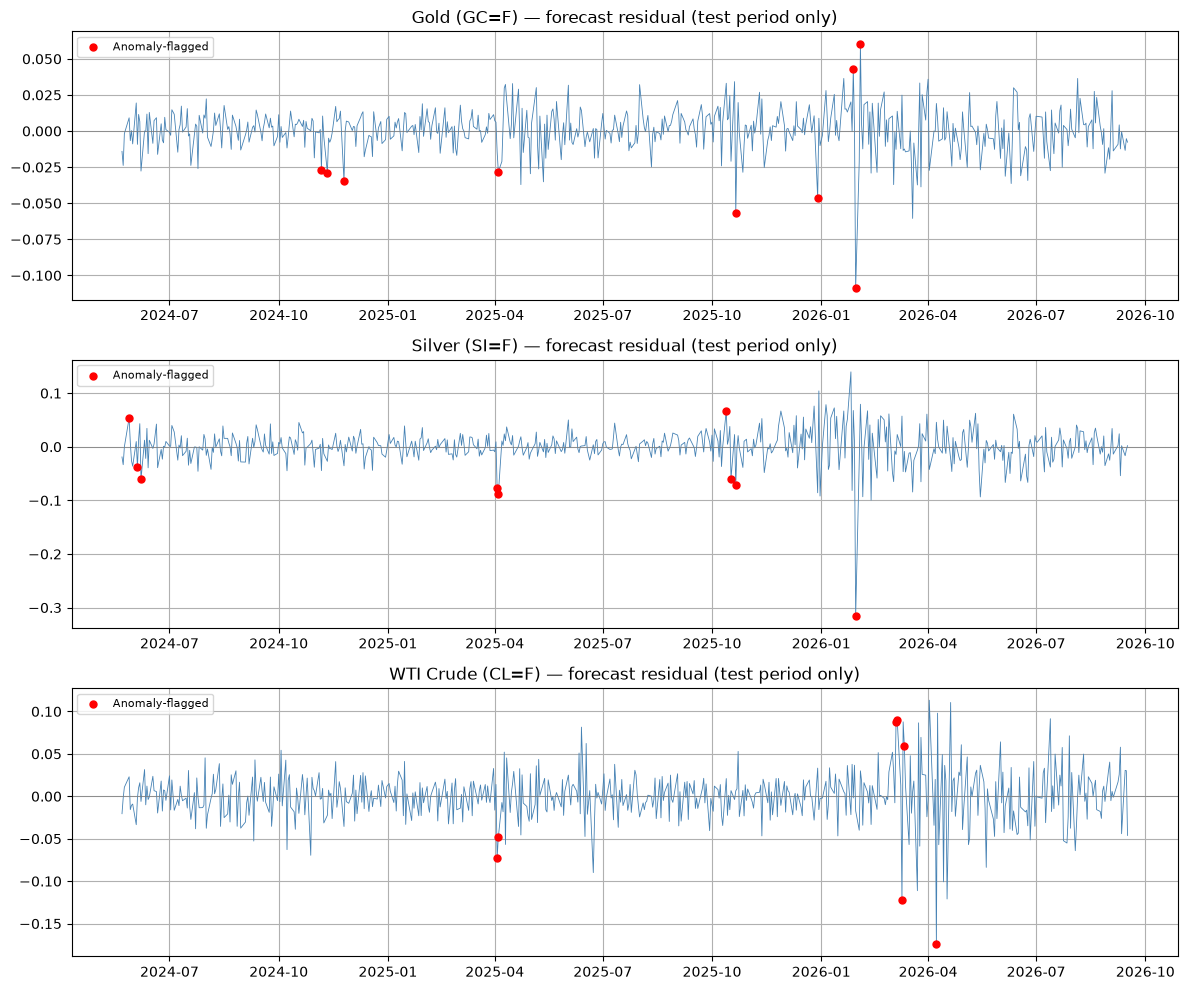

In [7]:
fig, axes = plt.subplots(3, 1, figsize=(12, 10), sharex=False)
for ax, (key, label) in zip(axes, TICKERS.items()):
    residual = forecasts[key]["residual"]
    ax.plot(residual.index, residual, linewidth=0.6, color="steelblue")

    flagged_dates = sorted(z_flags[key] & set(residual.index))
    ax.scatter(flagged_dates, residual.loc[flagged_dates], color="red", s=25, zorder=5, label="Anomaly-flagged")

    ax.axhline(0, color="gray", linewidth=0.5)
    ax.set_title(f"{label} — forecast residual (test period only)")
    ax.legend(loc="upper left", fontsize=8)
plt.tight_layout()
plt.show()


**Note on the test window:** with an 80/20 split on ~11 years of data, the test period covers
roughly the last ~2 years — which includes the January 2026 precious-metals crash, but *not*
the 2020 oil event (that's in the training data). That's fine: it just means this particular
check validates against a different known event than the ones used earlier.

## 6. Summary & next steps

- [ ] Confirm the January 2026 crash shows up as a residual spike in the gold/silver charts above
- [ ] If `ratio_flagged_vs_unflagged` is well above 1 for all three, that's a strong, honest
      cross-validation result for the writeup — two independent methods agreeing
- [ ] Legitimate "with more time" extensions: ACF/PACF-driven order selection, periodic refit
      during the walk-forward, GARCH for volatility itself rather than SARIMAX on returns
- [ ] Move to Step 5: deploy the pipeline as an interactive Streamlit dashboard